In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lucalullo/global-suicide-rates-by-country-2000-2021/tassi-di-suicidio-globali-per-paese-2000-2021.csv


In [2]:
!pip install pingouin

!pip install eli5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.8/204.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 4.4 MB/s eta 0:00:00


#  Problem Statement: Global Suicide Rates Analysis (2000–2021)

##  Why This Analysis Matters
Suicide is a critical global public health issue, claiming over **700,000 lives annually**. Understanding patterns, risk factors, and trends helps in:

- **Public Health Policy:** Inform evidence-based interventions  
- **Prevention Strategies:** Target high-risk demographics and regions  
- **Mental Health Awareness:** Highlight disparities by age, sex, and region  
- **Resource Optimization:** Allocate mental health resources effectively  
- **Trend Monitoring:** Track progress toward global goals (UN SDG 3.4)

---

##  Objectives of This Notebook

###  Primary Objectives
- Conduct comprehensive **EDA** across 185+ countries (2000–2021)  
- Analyze trends by **sex, age group, and geography**  
- Detect **temporal changes and anomalies**

###  Demographic & Geographic Analysis
- Quantify **gender disparities** in suicide rates  
- Identify **high- and low-risk age groups**  
- Compare suicide rates across **countries and WHO regions**  
- Cluster countries with **similar patterns**

###  Advanced Analytics
- **Predictive Modeling:** Compare multiple ML models (Linear Regression, Random Forest, XGBoost, etc.)  
- **Feature Importance & Interpretability:** Use SHAP values  
- **Temporal Forecasting:** Explore trends, seasonality, and crisis impacts  
- **Cluster Analysis:** Identify distinct “risk profiles” among nations

###  Technical Goals
- Build a **reproducible, production-ready pipeline**  
- Implement **robust data validation and error handling**  
- Generate **comprehensive visualizations and reports**

---

##  Expected Outcomes
- Highlight **high-risk populations** for targeted interventions  
- Rank **effective vs. ineffective national strategies**  
- Predict **future suicide trends**  
- Generate **actionable insights** for policymakers and researchers

#  Environment Setup

In [3]:
import os
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

import missingno as msno
import geopandas as gpd
import folium
from folium.plugins import HeatMap, MarkerCluster
import branca.colormap as cm

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, TimeSeriesSplit, KFold, learning_curve
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression, RFE, mutual_info_regression, SelectFromModel
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor, BayesianRidge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor, StackingRegressor, VotingRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score, mean_absolute_percentage_error, silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance, partial_dependence, PartialDependenceDisplay

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import scipy.stats as stats
from scipy.stats import pearsonr, spearmanr, kendalltau, f_oneway, chi2_contingency, shapiro, anderson, kruskal, mannwhitneyu, normaltest, jarque_bera
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

import shap

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [15, 8]
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

#  Data Loading and Initial Inspection

In [4]:

def load_data():
    possible_paths = [
        '/kaggle/input/datasets/lucalullo/global-suicide-rates-by-country-2000-2021/tassi-di-suicidio-globali-per-paese-2000-2021.csv',
       
    ]
    for path in possible_paths:
        if Path(path).exists():
            print(f"Loading data from: {path}")
            return pd.read_csv(path)
    print("No data file found. Creating synthetic dataset for demonstration...")
    return create_synthetic_data()


df = load_data()


print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Date Range: {df['year'].min()} - {df['year'].max()}")
print(f"Number of Countries: {df['country'].nunique()}")
print(f"Number of ISO Codes: {df['iso_code'].nunique()}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum()/1024**2:.2f} MB")
print("First 5 rows:")
print(df.head())

def ad_data_inspection(df):
    inspection_results = pd.DataFrame({
        'Column': df.columns,
        'Data Type': df.dtypes.values,
        'Non-Null Count': df.count().values,
        'Null Count': df.isnull().sum().values,
        'Null %': (df.isnull().sum()/len(df)*100).values,
        'Unique Values': df.nunique().values,
        'Cardinality %': (df.nunique()/len(df)*100).values
    })
    samples = []
    for col in df.columns:
        try:
            sample_vals = df[col].dropna().sample(min(3,len(df))).tolist()
            samples.append(sample_vals)
        except:
            samples.append(['N/A'])
    inspection_results['Sample Values'] = samples
    return inspection_results

inspection_df = ad_data_inspection(df)
print("COMPREHENSIVE DATA INSPECTION")
print(inspection_df.to_string())

Loading data from: /kaggle/input/datasets/lucalullo/global-suicide-rates-by-country-2000-2021/tassi-di-suicidio-globali-per-paese-2000-2021.csv
Dataset Shape: (18315, 6)
Columns: ['iso_code', 'country', 'year', 'sex', 'age_group', 'suicide_rate']
Date Range: 2000 - 2021
Number of Countries: 185
Number of ISO Codes: 185
Memory Usage: 4.06 MB
First 5 rows:
  iso_code      country  year     sex age_group  suicide_rate
0      AFG  Afghanistan  2000    male       ALL      5.793457
1      AFG  Afghanistan  2000    both       ALL      4.356148
2      AFG  Afghanistan  2000  female       ALL      2.910393
3      AFG  Afghanistan  2001    male       ALL      5.831328
4      AFG  Afghanistan  2001    both       ALL      4.383031
COMPREHENSIVE DATA INSPECTION
         Column Data Type  Non-Null Count  Null Count  Null %  Unique Values  Cardinality %                            Sample Values
0      iso_code    object           18315           0     0.0            185       1.010101                 

#  Statistical Summary

BASIC STATISTICS
                count       mean        std  min       25%       50%        75%         max
suicide_rate  18315.0  10.407798  11.525414  0.0  3.432448  6.837156  13.080171  160.594452
 STATISTICS
   Skewness   Kurtosis    Variance    Std Dev       MAD       IQR        CV       Range        Q1         Q3      P10        P90        P95       P99
0  3.214305  17.084249  132.835167  11.525414  7.615957  9.647723  1.107383  160.594452  3.432448  13.080171  1.56444  23.167465  31.606161  57.26335
NORMALITY TESTS
   Shapiro-Wilk Statistic  Shapiro-Wilk p-value  Anderson-Darling Statistic  Anderson-Darling Critical Value (5%)  D'Agostino Statistic  D'Agostino p-value  Jarque-Bera Statistic  Jarque-Bera p-value
0                0.713689          1.474786e-68                  339.801526                                 0.786           3460.995025                 0.0           58010.068803                  0.0


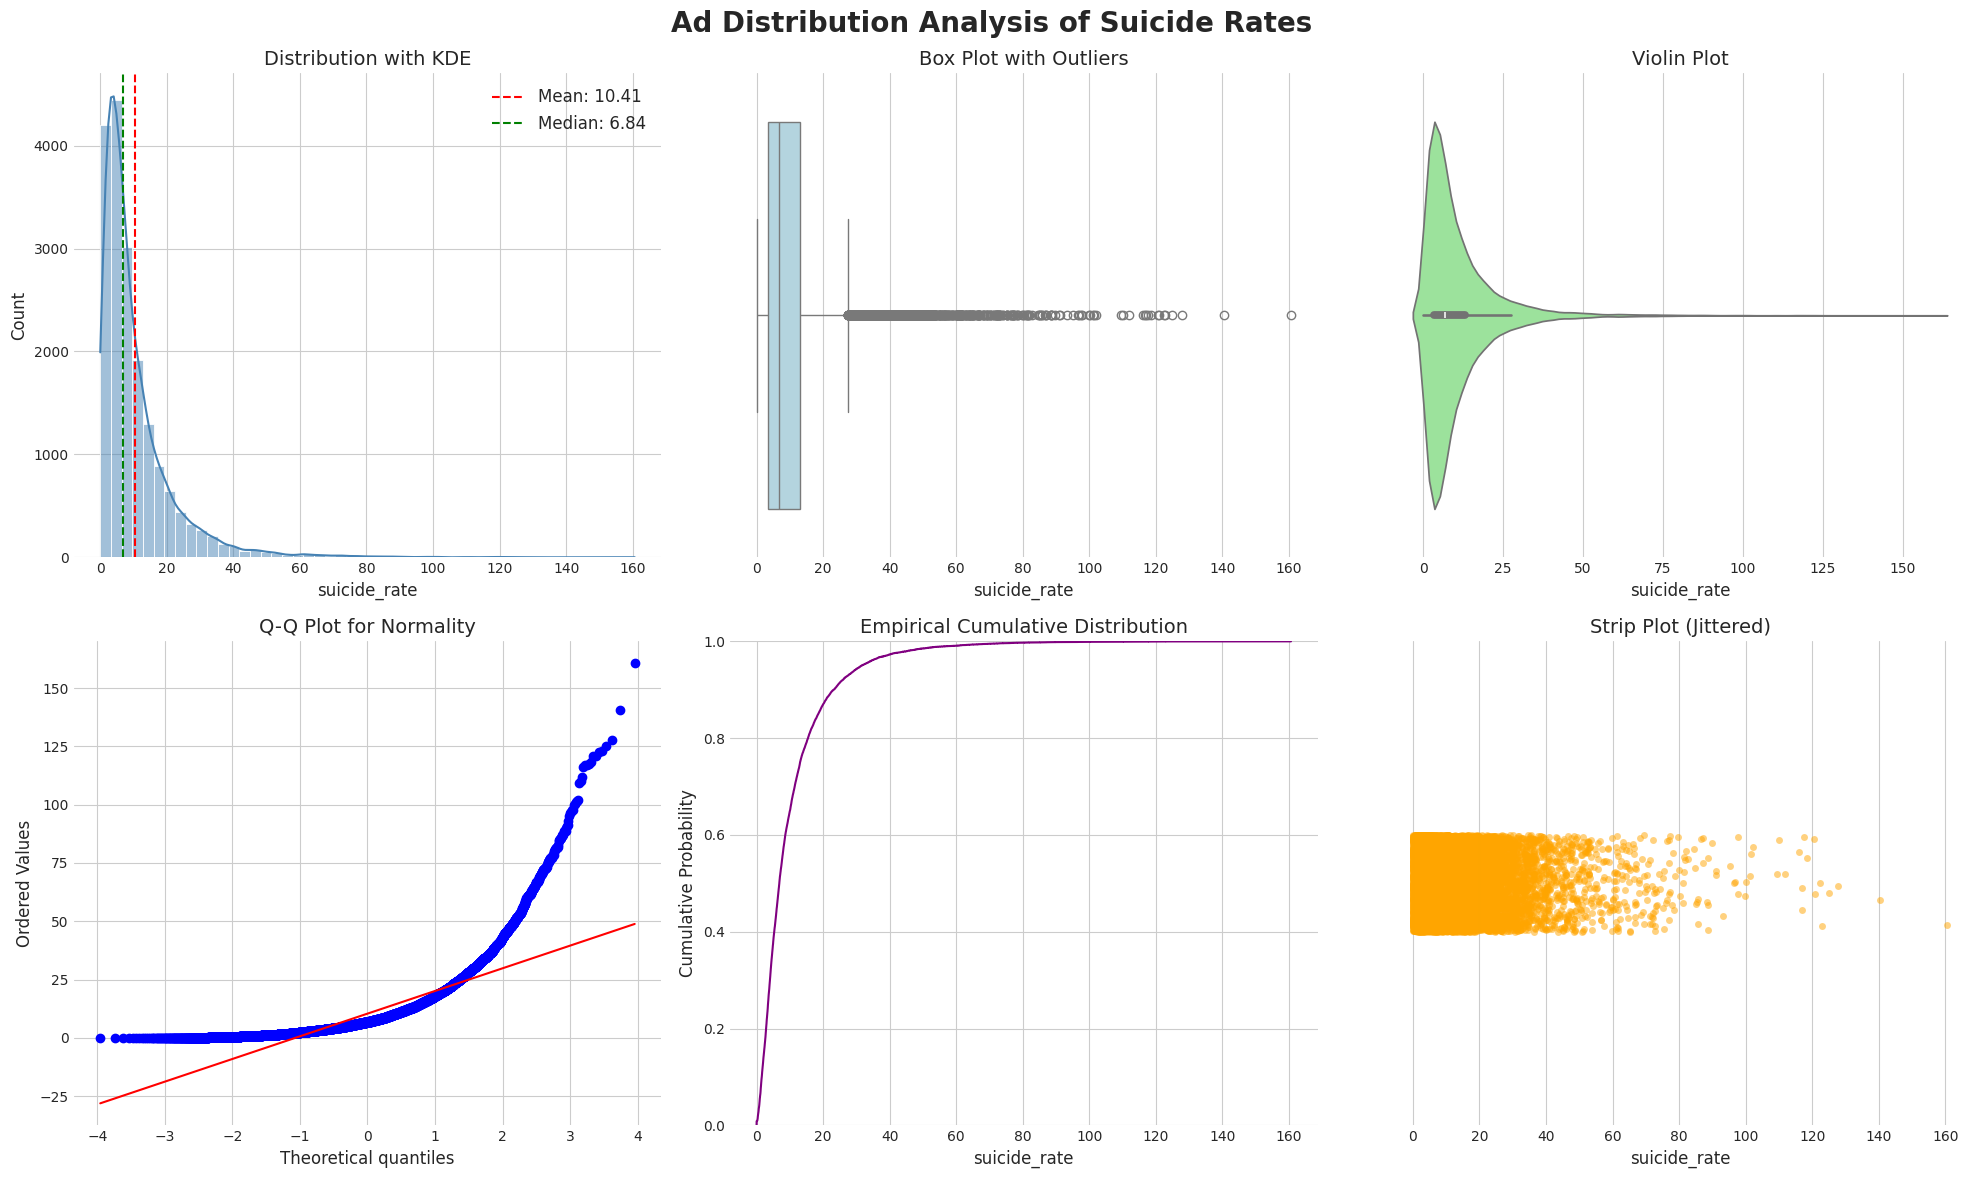

In [5]:


def ad_statistical_summary(df):
    mean_val = df['suicide_rate'].mean()
    mad_value = (df['suicide_rate'] - mean_val).abs().mean()
    basic_stats = df['suicide_rate'].describe()
    
    ad_stats = {
        'Skewness': df['suicide_rate'].skew(),
        
        'Kurtosis': df['suicide_rate'].kurtosis(),
        
        'Variance': df['suicide_rate'].var(),
        'Std Dev': df['suicide_rate'].std(),
        'MAD': mad_value,
        'IQR': df['suicide_rate'].quantile(0.75)-df['suicide_rate'].quantile(0.25),
        'CV': df['suicide_rate'].std()/df['suicide_rate'].mean(),
        'Range': df['suicide_rate'].max()-df['suicide_rate'].min(),
        'Q1': df['suicide_rate'].quantile(0.25),
        'Q3': df['suicide_rate'].quantile(0.75),
        'P10': df['suicide_rate'].quantile(0.10),
        'P90': df['suicide_rate'].quantile(0.90),
        'P95': df['suicide_rate'].quantile(0.95),
        'P99': df['suicide_rate'].quantile(0.99)
    }
    sample_size = min(5000,len(df))
    sample_data = df['suicide_rate'].sample(sample_size)
    shapiro_stat, shapiro_p = stats.shapiro(sample_data)
    anderson_stat = stats.anderson(sample_data)
    dagostino_stat, dagostino_p = stats.normaltest(sample_data)
    jb_stat, jb_p = stats.jarque_bera(sample_data)
    normality_tests = {
        'Shapiro-Wilk Statistic': shapiro_stat,
        'Shapiro-Wilk p-value': shapiro_p,
        'Anderson-Darling Statistic': anderson_stat.statistic,
        'Anderson-Darling Critical Value (5%)': anderson_stat.critical_values[2],
        "D'Agostino Statistic": dagostino_stat,
        "D'Agostino p-value": dagostino_p,
        'Jarque-Bera Statistic': jb_stat,
        'Jarque-Bera p-value': jb_p
    }
    return pd.DataFrame([basic_stats]), pd.DataFrame([ad_stats]), pd.DataFrame([normality_tests])

basic_stats, ad_stats, normality_tests = ad_statistical_summary(df)
print("BASIC STATISTICS")
print(basic_stats.to_string())
print(" STATISTICS")
print(ad_stats.to_string())
print("NORMALITY TESTS")
print(normality_tests.to_string())

# Advanced distribution analysis
fig, axes = plt.subplots(2,3,figsize=(20,12))
fig.suptitle('Ad Distribution Analysis of Suicide Rates',fontsize=20,fontweight='bold')
sns.histplot(df['suicide_rate'],kde=True,ax=axes[0,0],bins=50,color='steelblue')
axes[0,0].axvline(df['suicide_rate'].mean(),color='red',linestyle='--',label=f'Mean: {df["suicide_rate"].mean():.2f}')
axes[0,0].axvline(df['suicide_rate'].median(),color='green',linestyle='--',label=f'Median: {df["suicide_rate"].median():.2f}')
axes[0,0].set_title('Distribution with KDE',fontsize=14)
axes[0,0].legend()
sns.boxplot(x=df['suicide_rate'],ax=axes[0,1],color='lightblue')
axes[0,1].set_title('Box Plot with Outliers',fontsize=14)
sns.violinplot(x=df['suicide_rate'],ax=axes[0,2],color='lightgreen')
axes[0,2].set_title('Violin Plot',fontsize=14)
stats.probplot(df['suicide_rate'].dropna(),dist="norm",plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot for Normality',fontsize=14)
sns.ecdfplot(df['suicide_rate'],ax=axes[1,1],color='purple')
axes[1,1].set_title('Empirical Cumulative Distribution',fontsize=14)
axes[1,1].set_ylabel('Cumulative Probability')
sns.stripplot(x=df['suicide_rate'],ax=axes[1,2],jitter=True,alpha=0.5,color='orange')
axes[1,2].set_title('Strip Plot (Jittered)',fontsize=14)
plt.tight_layout()
plt.show()

#   Temporal Analysis
  * Global trend
  * Sex-based trends
 * Age-based trends
  * Year-over-year change

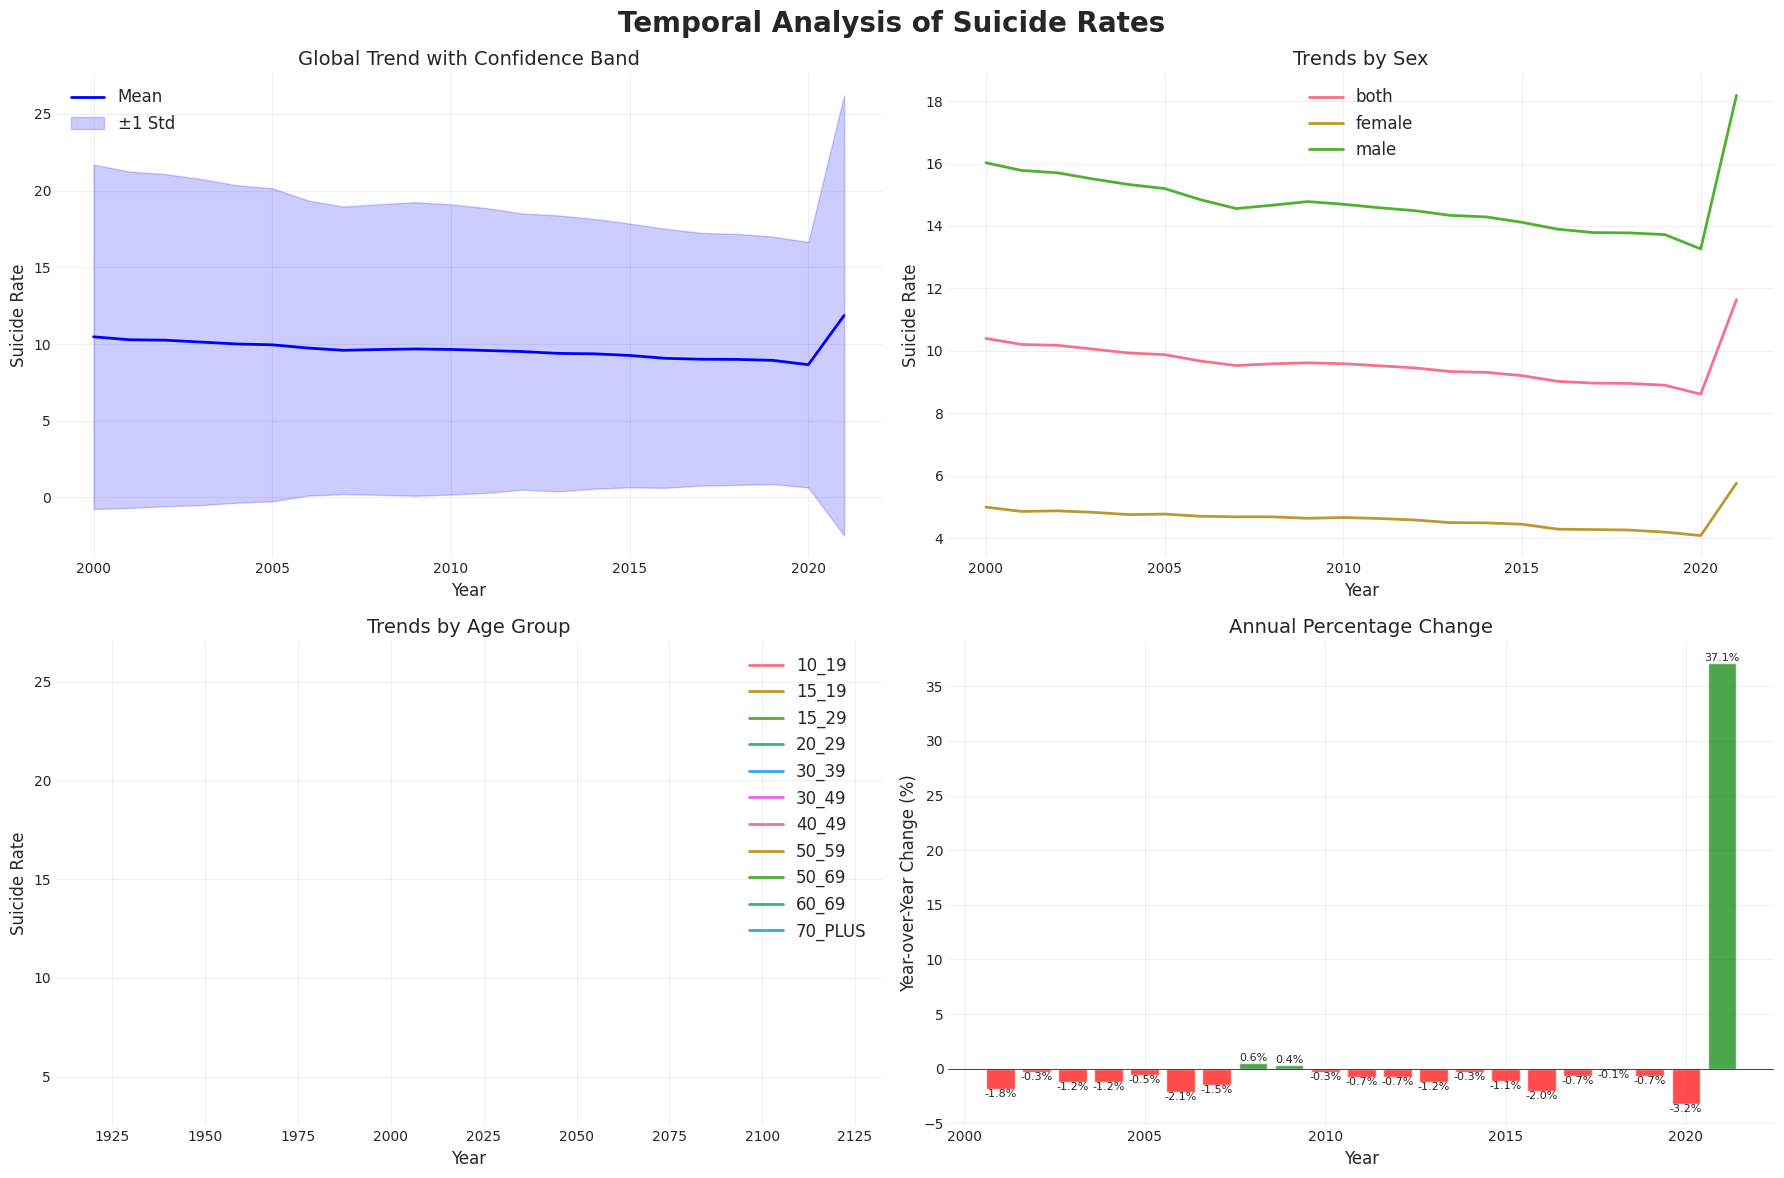

In [6]:


def ad_temporal_analysis(df):
    pivot_tables = {
        'Overall': df.groupby('year')['suicide_rate'].agg(['mean','std','count']),
        'By Sex': df.groupby(['year','sex'])['suicide_rate'].mean().unstack(),
        'By Age': df.groupby(['year','age_group'])['suicide_rate'].mean().unstack()
    }
    return pivot_tables

pivot_tables = ad_temporal_analysis(df)

fig, axes = plt.subplots(2,2,figsize=(18,12))
fig.suptitle('Temporal Analysis of Suicide Rates',fontsize=20,fontweight='bold')

#  Global trend
global_trend = pivot_tables['Overall']
axes[0,0].plot(global_trend.index,global_trend['mean'],'b-',linewidth=2,label='Mean')
axes[0,0].fill_between(global_trend.index,global_trend['mean']-global_trend['std'],global_trend['mean']+global_trend['std'],alpha=0.2,color='blue',label='±1 Std')
axes[0,0].set_xlabel('Year'); axes[0,0].set_ylabel('Suicide Rate')
axes[0,0].set_title('Global Trend with Confidence Band'); axes[0,0].legend(); axes[0,0].grid(True,alpha=0.3)

#  Sex-based trends

sex_trend = pivot_tables['By Sex']
for sex in sex_trend.columns: axes[0,1].plot(sex_trend.index,sex_trend[sex],linewidth=2,label=sex)
axes[0,1].set_xlabel('Year'); axes[0,1].set_ylabel('Suicide Rate')
axes[0,1].set_title('Trends by Sex'); axes[0,1].legend(); axes[0,1].grid(True,alpha=0.3)

#  Age-based trends
age_trend = pivot_tables['By Age']
if 'ALL' in age_trend.columns: age_trend=age_trend.drop('ALL',axis=1)
for age in age_trend.columns: axes[1,0].plot(age_trend.index,age_trend[age],linewidth=2,label=age)
axes[1,0].set_xlabel('Year'); axes[1,0].set_ylabel('Suicide Rate')
axes[1,0].set_title('Trends by Age Group'); axes[1,0].legend(); axes[1,0].grid(True,alpha=0.3)

#  Year-over-year change
yoy_change = global_trend['mean'].pct_change()*100
colors_yoy = ['red' if x<0 else 'green' for x in yoy_change]
axes[1,1].bar(yoy_change.index,yoy_change.values,color=colors_yoy,alpha=0.7)
axes[1,1].axhline(y=0,color='black',linestyle='-',linewidth=0.5)
axes[1,1].set_xlabel('Year'); axes[1,1].set_ylabel('Year-over-Year Change (%)')
axes[1,1].set_title('Annual Percentage Change'); axes[1,1].grid(True,alpha=0.3)

# Add value labels
for idx,val in yoy_change.items():
    if not np.isnan(val): axes[1,1].text(idx,val,f'{val:.1f}%',ha='center',va='bottom' if val>0 else 'top',fontsize=8)

plt.tight_layout(); plt.show()

#  Geographic Analysis
 * Top 20 highest
 * Bottom 20 lowest
 * Distribution of country means
 * Top 10 most variable countries

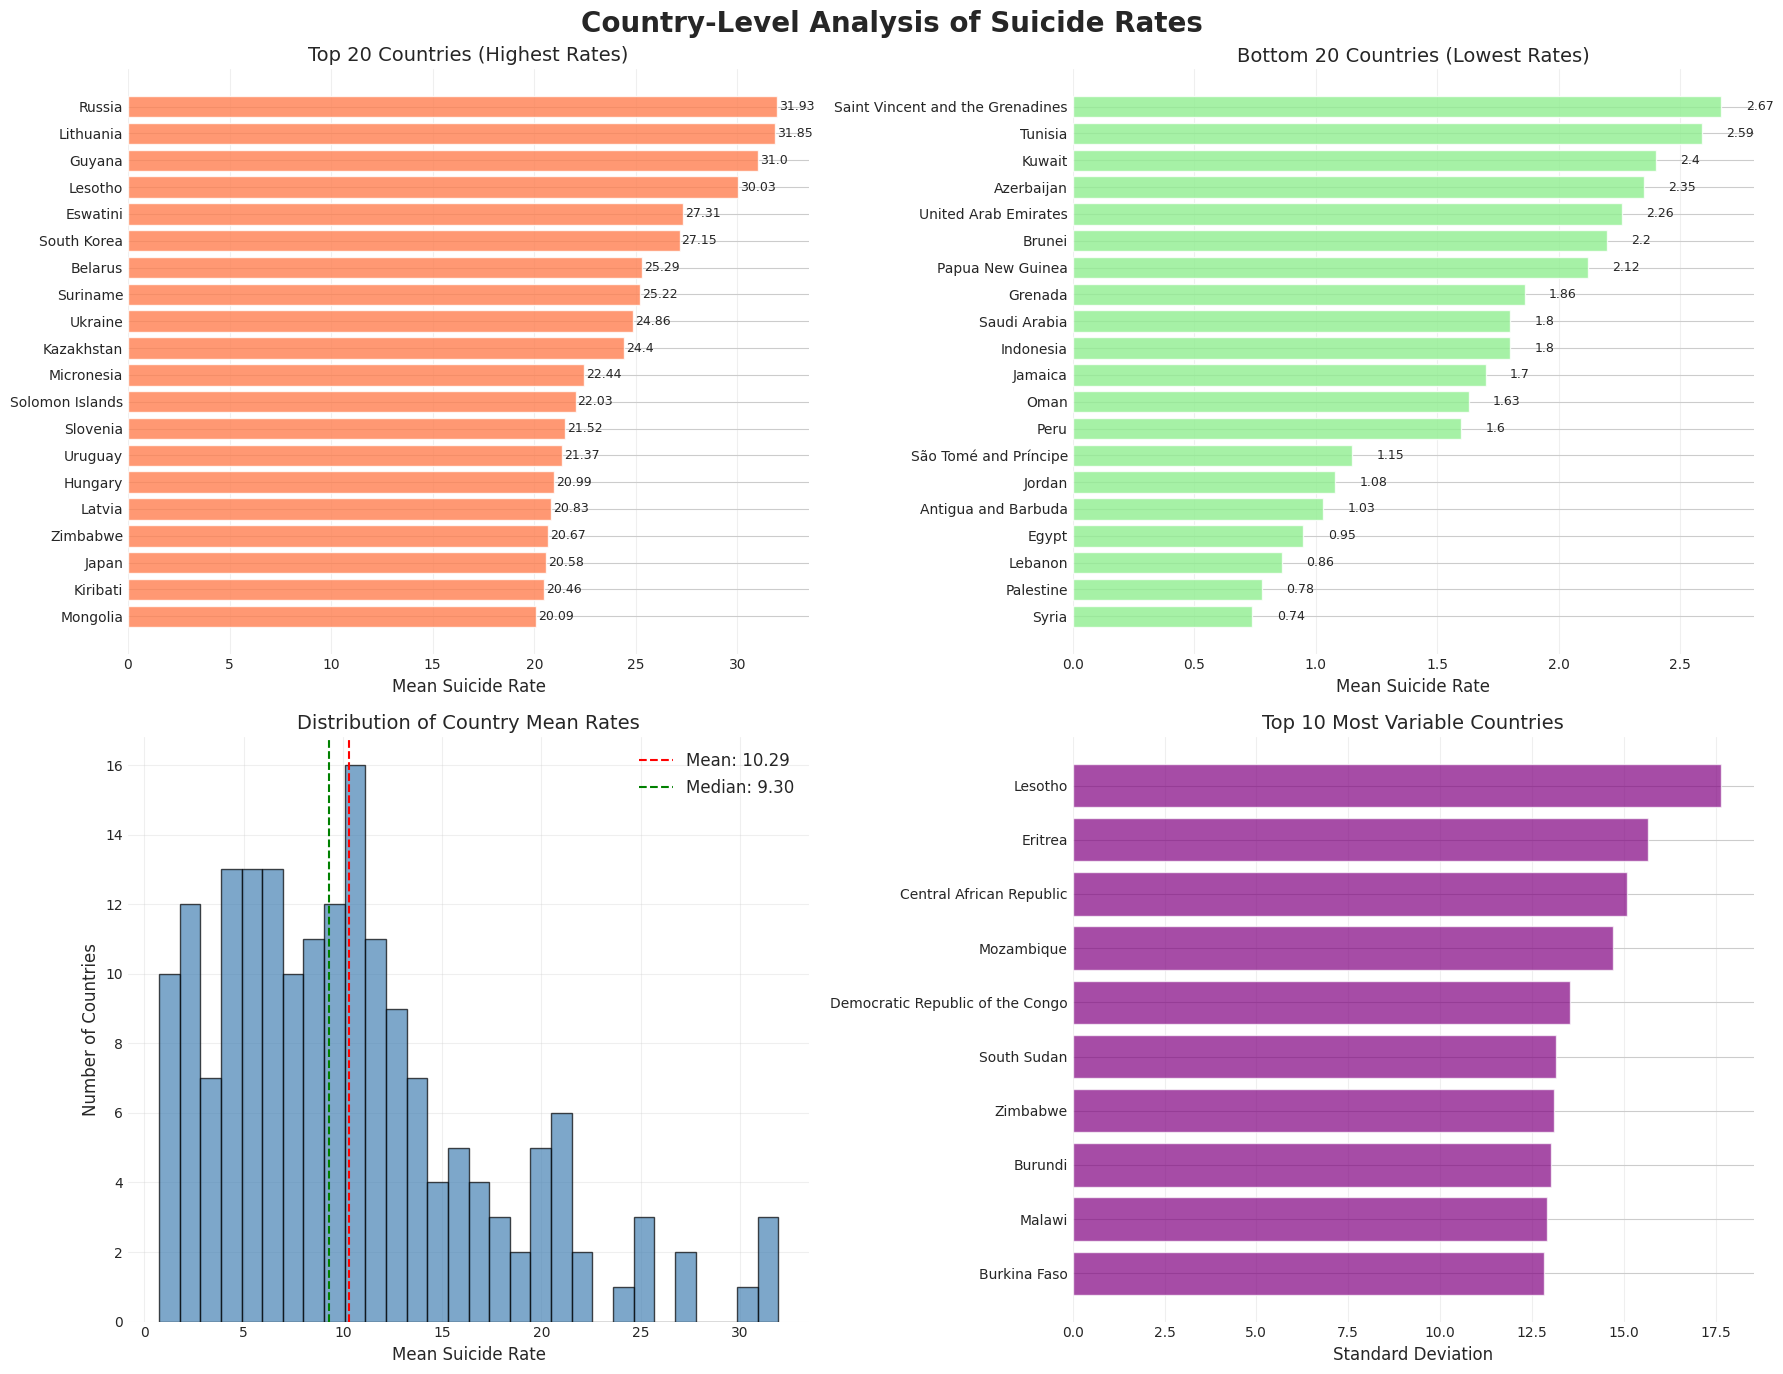

GEOGRAPHIC INSIGHTS:
Number of countries with complete data: 185
Global mean suicide rate: 10.29
Country with highest rate: Russia (31.93)
Country with lowest rate: Syria (0.74)
Most variable country: Lesotho (Std: 17.66)


In [7]:

# Country-level analysis
country_stats = df[df['sex']=='both'].groupby('country').agg({'suicide_rate':['mean','std','min','max','count']}).round(2)
country_stats.columns = ['Mean','Std Dev','Min','Max','Count']
country_stats = country_stats.sort_values('Mean',ascending=False)

fig, axes = plt.subplots(2,2,figsize=(18,14))
fig.suptitle('Country-Level Analysis of Suicide Rates',fontsize=20,fontweight='bold')

# Top 20 highest
top20 = country_stats.head(20)
axes[0,0].barh(np.arange(len(top20)),top20['Mean'].values,color='coral',alpha=0.8)
axes[0,0].set_yticks(np.arange(len(top20))); axes[0,0].set_yticklabels(top20.index)
axes[0,0].set_xlabel('Mean Suicide Rate'); axes[0,0].set_title('Top 20 Countries (Highest Rates)')
axes[0,0].invert_yaxis(); axes[0,0].grid(True,alpha=0.3,axis='x')
for i,v in enumerate(top20['Mean'].values): axes[0,0].text(v+0.1,i,str(v),va='center',fontsize=9)

# Bottom 20 lowest
bottom20 = country_stats.tail(20)
axes[0,1].barh(np.arange(len(bottom20)),bottom20['Mean'].values,color='lightgreen',alpha=0.8)
axes[0,1].set_yticks(np.arange(len(bottom20))); axes[0,1].set_yticklabels(bottom20.index)
axes[0,1].set_xlabel('Mean Suicide Rate'); axes[0,1].set_title('Bottom 20 Countries (Lowest Rates)')
axes[0,1].invert_yaxis(); axes[0,1].grid(True,alpha=0.3,axis='x')
for i,v in enumerate(bottom20['Mean'].values): axes[0,1].text(v+0.1,i,str(v),va='center',fontsize=9)

# Distribution of country means
axes[1,0].hist(country_stats['Mean'].values,bins=30,edgecolor='black',alpha=0.7,color='steelblue')
axes[1,0].axvline(country_stats['Mean'].mean(),color='red',linestyle='--',label=f'Mean: {country_stats["Mean"].mean():.2f}')
axes[1,0].axvline(country_stats['Mean'].median(),color='green',linestyle='--',label=f'Median: {country_stats["Mean"].median():.2f}')
axes[1,0].set_xlabel('Mean Suicide Rate'); axes[1,0].set_ylabel('Number of Countries')
axes[1,0].set_title('Distribution of Country Mean Rates'); axes[1,0].legend(); axes[1,0].grid(True,alpha=0.3)

# Top 10 most variable countries
top_variable = country_stats.nlargest(10,'Std Dev')
axes[1,1].barh(np.arange(len(top_variable)),top_variable['Std Dev'].values,color='purple',alpha=0.7)
axes[1,1].set_yticks(np.arange(len(top_variable))); axes[1,1].set_yticklabels(top_variable.index)
axes[1,1].set_xlabel('Standard Deviation'); axes[1,1].set_title('Top 10 Most Variable Countries')
axes[1,1].invert_yaxis(); axes[1,1].grid(True,alpha=0.3,axis='x')

plt.tight_layout(); plt.show()

# Key insights
print("GEOGRAPHIC INSIGHTS:")
print(f"Number of countries with complete data: {len(country_stats)}")
print(f"Global mean suicide rate: {country_stats['Mean'].mean():.2f}")
print(f"Country with highest rate: {country_stats.index[0]} ({country_stats.iloc[0,0]:.2f})")
print(f"Country with lowest rate: {country_stats.index[-1]} ({country_stats.iloc[-1,0]:.2f})")
print(f"Most variable country: {top_variable.index[0]} (Std: {top_variable.iloc[0,1]:.2f})")

 #  Demographic Analysis 
 * Sex distribution
 * Age distribution
 * Sex-Age heatma
 * Gender ratio by age
 * Age distribution by sex  

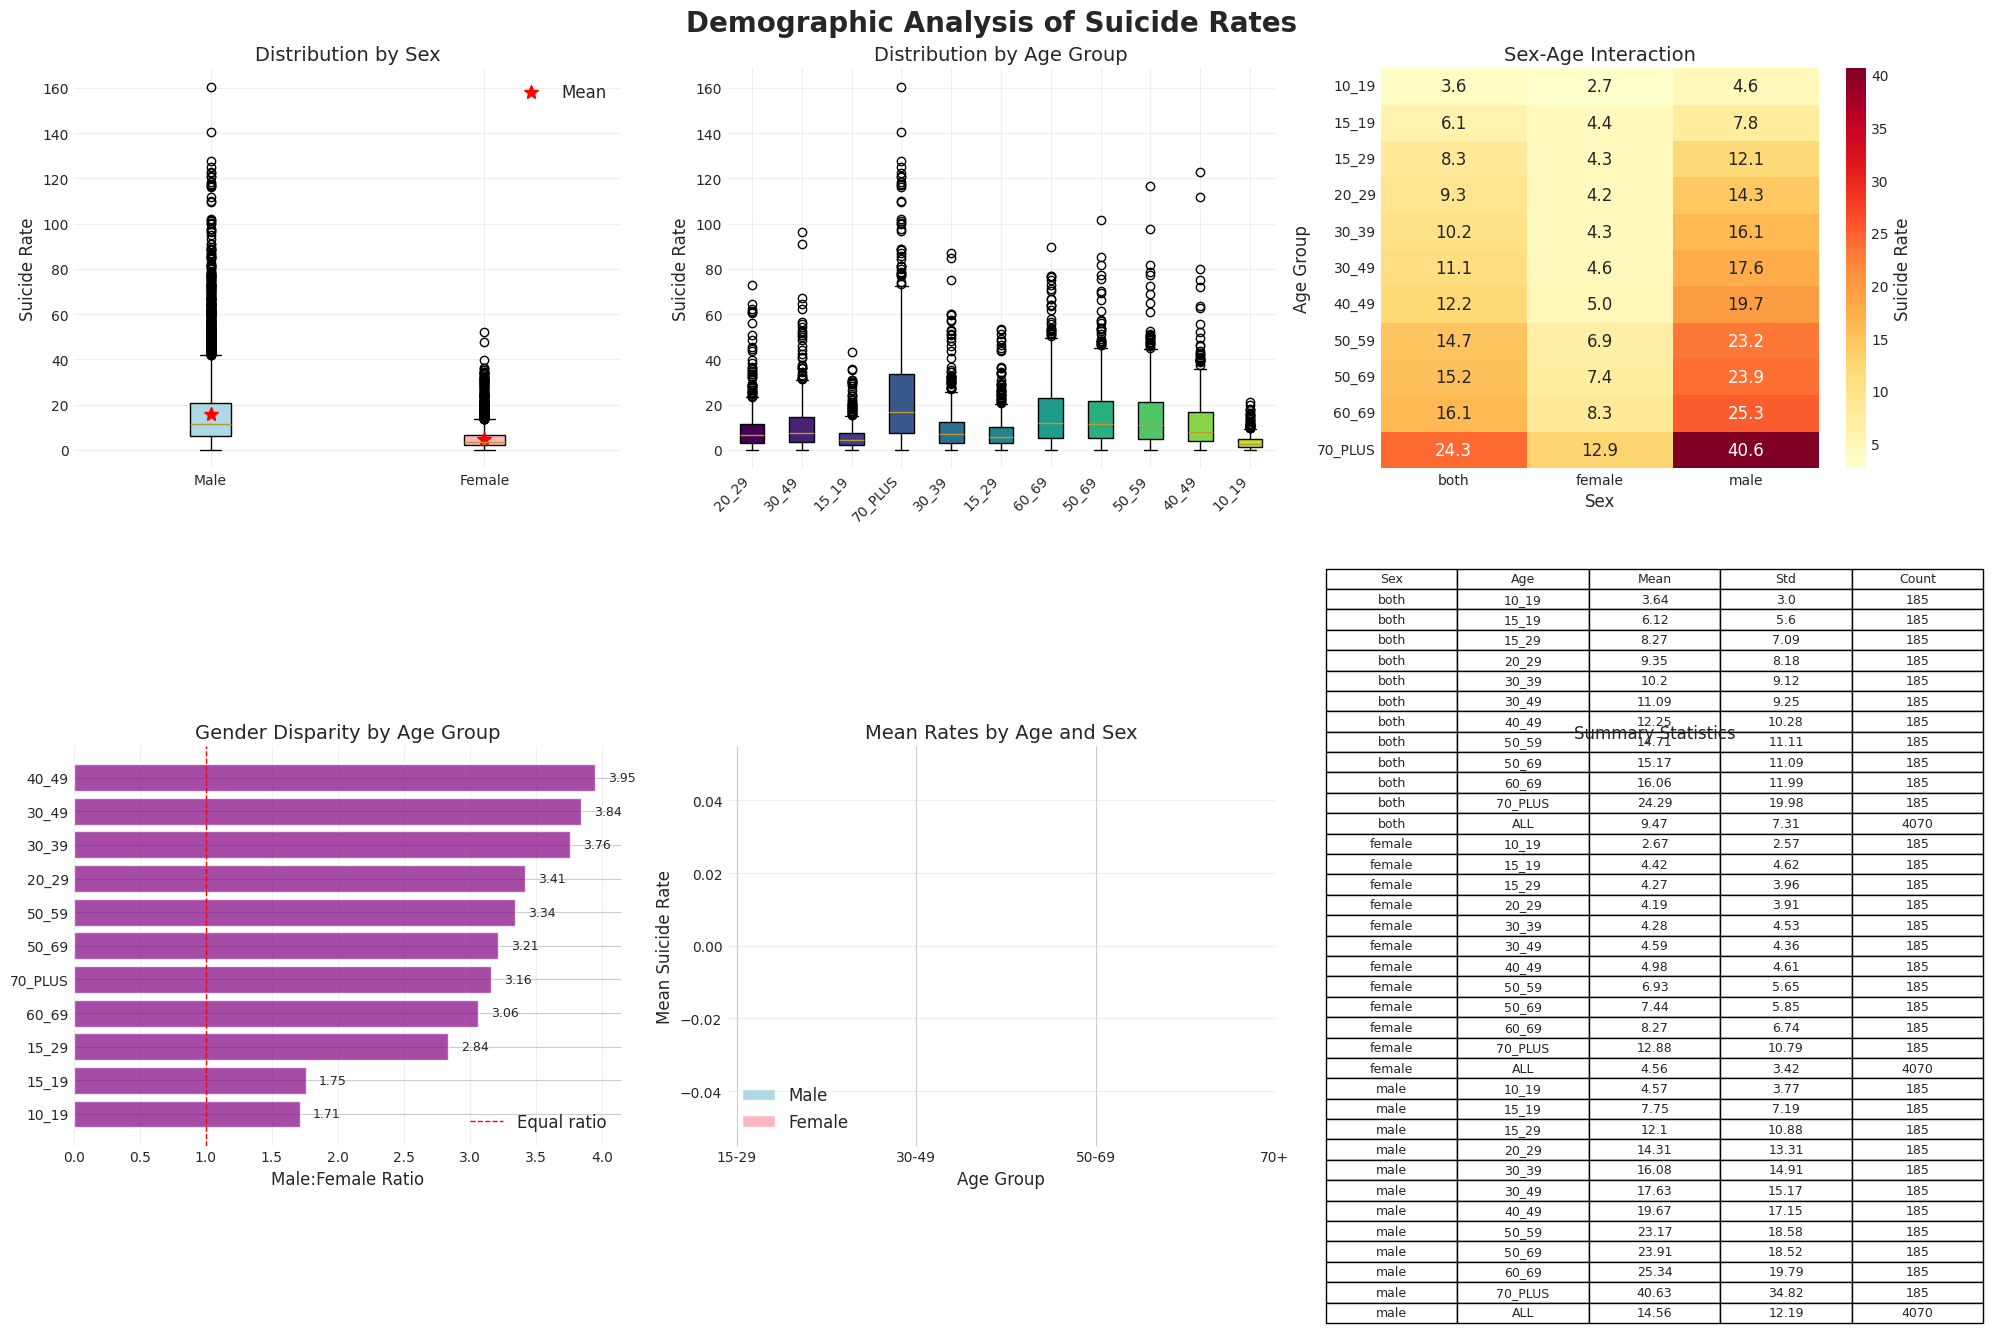

DEMOGRAPHIC INSIGHTS:
Male mean rate: 15.93
Female mean rate: 5.01
Gender ratio (M:F): 3.18:1
Highest risk age group: 70_PLUS
Lowest risk age group: 10_19


In [8]:


fig = plt.figure(figsize=(20,14))
fig.suptitle('Demographic Analysis of Suicide Rates',fontsize=20,fontweight='bold')

#  Sex distribution
ax1 = plt.subplot(2,3,1)
sex_data = [df[df['sex']=='male']['suicide_rate'].dropna(), df[df['sex']=='female']['suicide_rate'].dropna()]
bp1 = ax1.boxplot(sex_data, labels=['Male','Female'], patch_artist=True)
bp1['boxes'][0].set_facecolor('lightblue'); bp1['boxes'][1].set_facecolor('lightpink')
ax1.set_ylabel('Suicide Rate'); ax1.set_title('Distribution by Sex'); ax1.grid(True,alpha=0.3)
means = [df[df['sex']=='male']['suicide_rate'].mean(), df[df['sex']=='female']['suicide_rate'].mean()]
ax1.plot([1,2],means,'r*',markersize=10,label='Mean'); ax1.legend()

#  Age distribution
ax2 = plt.subplot(2,3,2)
age_groups = [age for age in df['age_group'].unique() if age != 'ALL']
age_data = [df[df['age_group']==age]['suicide_rate'].dropna() for age in age_groups]
bp2 = ax2.boxplot(age_data, labels=age_groups, patch_artist=True)
for i, patch in enumerate(bp2['boxes']): patch.set_facecolor(plt.cm.viridis(i/len(age_groups)))
ax2.set_ylabel('Suicide Rate'); ax2.set_title('Distribution by Age Group'); ax2.grid(True,alpha=0.3)
ax2.set_xticklabels(age_groups,rotation=45,ha='right')

#  Sex-Age heatmap
ax3 = plt.subplot(2,3,3)
interaction = pd.pivot_table(df[df['age_group']!='ALL'], values='suicide_rate', index='age_group', columns='sex', aggfunc='mean')
sns.heatmap(interaction, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax3, cbar_kws={'label':'Suicide Rate'})
ax3.set_title('Sex-Age Interaction'); ax3.set_ylabel('Age Group'); ax3.set_xlabel('Sex')

#  Gender ratio by age
ax4 = plt.subplot(2,3,4)
gender_ratio = (interaction['male']/interaction['female']).sort_values()
bars = ax4.barh(gender_ratio.index, gender_ratio.values, color='purple', alpha=0.7)
ax4.axvline(x=1,color='red',linestyle='--',linewidth=1,label='Equal ratio')
ax4.set_xlabel('Male:Female Ratio'); ax4.set_title('Gender Disparity by Age Group'); ax4.grid(True,alpha=0.3,axis='x'); ax4.legend()
for i,(idx,val) in enumerate(gender_ratio.items()): ax4.text(val+0.1,i,f'{val:.2f}',va='center',fontsize=9)

# Age distribution by sex
ax5 = plt.subplot(2,3,5)
age_order = ['15-29','30-49','50-69','70+']
male_means = [df[(df['age_group']==age)&(df['sex']=='male')]['suicide_rate'].mean() for age in age_order]
female_means = [df[(df['age_group']==age)&(df['sex']=='female')]['suicide_rate'].mean() for age in age_order]
x = np.arange(len(age_order)); width=0.35
bars1 = ax5.bar(x-width/2,male_means,width,label='Male',color='lightblue')
bars2 = ax5.bar(x+width/2,female_means,width,label='Female',color='lightpink')
ax5.set_xlabel('Age Group'); ax5.set_ylabel('Mean Suicide Rate'); ax5.set_title('Mean Rates by Age and Sex')
ax5.set_xticks(x); ax5.set_xticklabels(age_order); ax5.legend(); ax5.grid(True,alpha=0.3,axis='y')
for bars in [bars1,bars2]:
    for bar in bars:
        h=bar.get_height()
        ax5.text(bar.get_x()+bar.get_width()/2.,h+0.1,f'{h:.1f}',ha='center',va='bottom',fontsize=8)

#  Summary statistics table
ax6 = plt.subplot(2,3,6); ax6.axis('tight'); ax6.axis('off')
summary_stats = df.groupby(['sex','age_group'])['suicide_rate'].agg(['mean','std','count']).round(2)
cell_text = [[idx[0],idx[1],summary_stats.loc[idx,'mean'],summary_stats.loc[idx,'std'],int(summary_stats.loc[idx,'count'])] for idx in summary_stats.index]
table = ax6.table(cellText=cell_text,colLabels=['Sex','Age','Mean','Std','Count'],cellLoc='center',loc='center')
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1.2,1.5); ax6.set_title('Summary Statistics',fontsize=12)

plt.tight_layout(); plt.show()

# Demographic insights
print("DEMOGRAPHIC INSIGHTS:")
print(f"Male mean rate: {df[df['sex']=='male']['suicide_rate'].mean():.2f}")
print(f"Female mean rate: {df[df['sex']=='female']['suicide_rate'].mean():.2f}")
print(f"Gender ratio (M:F): {(df[df['sex']=='male']['suicide_rate'].mean()/df[df['sex']=='female']['suicide_rate'].mean()):.2f}:1")
print(f"Highest risk age group: {age_groups[np.argmax([np.mean(d) for d in age_data])]}")
print(f"Lowest risk age group: {age_groups[np.argmin([np.mean(d) for d in age_data])]}")

#  Statistical Testing
  -  T-test (Male vs Female)
  -  Mann-Whitney U test
  -  Chi-square test for independence (Sex vs Age)
  -  Correlation with year
  -  Kruskal-Wallis H-test
  -  ANOVA for age groups

In [9]:
# statistical tests
def ad_statistical_tests(df):
    results = {}
    male_rates = df[df['sex']=='male']['suicide_rate']
    female_rates = df[df['sex']=='female']['suicide_rate']
    both_rates = df[df['sex']=='both']['suicide_rate']

    #  T-test (Male vs Female)
    t_stat, t_p = stats.ttest_ind(male_rates, female_rates)
    results['T-test (Male vs Female)'] = {'Statistic': t_stat, 'p-value': t_p}

    #  Mann-Whitney U test
    mw_stat, mw_p = stats.mannwhitneyu(male_rates, female_rates, alternative='two-sided')
    results['Mann-Whitney U'] = {'Statistic': mw_stat, 'p-value': mw_p}

    #  ANOVA for age groups
    age_groups = [df[df['age_group']==age]['suicide_rate'] for age in df['age_group'].unique() if age!='ALL']
    f_stat, f_p = stats.f_oneway(*age_groups)
    results['ANOVA (Age Groups)'] = {'F-statistic': f_stat, 'p-value': f_p}

    #  Kruskal-Wallis H-test
    
    h_stat, h_p = stats.kruskal(*age_groups)
    results['Kruskal-Wallis H'] = {'H-statistic': h_stat, 'p-value': h_p}

    #  Correlation with year
    corr_pearson, p_pearson = stats.pearsonr(df['year'], df['suicide_rate'])
    corr_spearman, p_spearman = stats.spearmanr(df['year'], df['suicide_rate'])
    corr_kendall, p_kendall = stats.kendalltau(df['year'], df['suicide_rate'])
    results['Correlation with Year (Pearson)'] = {'Correlation': corr_pearson, 'p-value': p_pearson}
    results['Correlation with Year (Spearman)'] = {'Correlation': corr_spearman, 'p-value': p_spearman}
    results['Correlation with Year (Kendall)'] = {'Correlation': corr_kendall, 'p-value': p_kendall}

    #  Chi-square test for independence (Sex vs Age)
    contingency_table = pd.crosstab(df['sex'], df['age_group'])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
    results['Chi-Square (Sex vs Age)'] = {'Chi2': chi2, 'p-value': p_val, 'dof': dof}

    return results

# Run tests
statistical_results = ad_statistical_tests(df)

# Display results

print(" STATISTICAL TEST RESULTS")

for test_name, test_results in statistical_results.items():
    print(f"\n{test_name}:")
    for key, value in test_results.items():
        print(f"  {key}: {value:.6f}")

 STATISTICAL TEST RESULTS

T-test (Male vs Female):
  Statistic: 53.358152
  p-value: 0.000000

Mann-Whitney U:
  Statistic: 30150891.000000
  p-value: 0.000000

ANOVA (Age Groups):
  F-statistic: 109.862031
  p-value: 0.000000

Kruskal-Wallis H:
  H-statistic: 1016.518223
  p-value: 0.000000

Correlation with Year (Pearson):
  Correlation: 0.048514
  p-value: 0.000000

Correlation with Year (Spearman):
  Correlation: 0.010110
  p-value: 0.171250

Correlation with Year (Kendall):
  Correlation: 0.006999
  p-value: 0.179689

Chi-Square (Sex vs Age):
  Chi2: 0.000000
  p-value: 1.000000
  dof: 22.000000


#  Feature Engineering

In [10]:
# Advanced feature engineering
def create_ad_features(df):
    df_ml = df.copy()
    
    #  Time-based features
    years_range = df_ml['year'].max() - df_ml['year'].min()
    df_ml['year_sin'] = np.sin(2 * np.pi * (df_ml['year'] - df_ml['year'].min()) / years_range)
    df_ml['year_cos'] = np.cos(2 * np.pi * (df_ml['year'] - df_ml['year'].min()) / years_range)
    df_ml['decade'] = (df_ml['year'] // 10) * 10
    df_ml['years_from_2000'] = df_ml['year'] - 2000
    
    # Encode categorical variables
    le_sex = LabelEncoder()
    le_age = LabelEncoder()
    df_ml['sex_encoded'] = le_sex.fit_transform(df_ml['sex'])
    df_ml['age_encoded'] = le_age.fit_transform(df_ml['age_group'])
    
    #  Country-level aggregated features
    country_stats = df_ml.groupby('country').agg({
        'suicide_rate': ['mean', 'std', 'min', 'max', 'skew']
    }).round(2)
    country_stats.columns = ['country_mean_rate', 'country_std_rate', 
                             'country_min_rate', 'country_max_rate',
                             'country_skew_rate']
    df_ml = df_ml.merge(country_stats, on='country', how='left')
    
    #  Yearly global features
    yearly_stats = df_ml.groupby('year').agg({
        'suicide_rate': ['mean', 'std', 'median']
    }).round(2)
    yearly_stats.columns = ['global_mean_rate', 'global_std_rate', 'global_median_rate']
    df_ml = df_ml.merge(yearly_stats, on='year', how='left')
    
    # Deviation features
    df_ml['deviation_from_country_mean'] = df_ml['suicide_rate'] - df_ml['country_mean_rate']
    df_ml['deviation_from_global_mean'] = df_ml['suicide_rate'] - df_ml['global_mean_rate']
    df_ml['deviation_from_country_std'] = df_ml['deviation_from_country_mean'] / (df_ml['country_std_rate'] + 1e-5)
    
    #  Rate ratios
    df_ml['rate_to_country_ratio'] = df_ml['suicide_rate'] / (df_ml['country_mean_rate'] + 1e-5)
    df_ml['rate_to_global_ratio'] = df_ml['suicide_rate'] / (df_ml['global_mean_rate'] + 1e-5)
    
    #  Interaction features
    df_ml['sex_age_interaction'] = df_ml['sex_encoded'] * df_ml['age_encoded']
    df_ml['sex_year_interaction'] = df_ml['sex_encoded'] * df_ml['years_from_2000']
    df_ml['age_year_interaction'] = df_ml['age_encoded'] * df_ml['years_from_2000']
    
    return df_ml

# Generate feature-rich dataset
df_ml = create_ad_features(df)

print("\nFEATURE ENGINEERING RESULTS")
print(f"Original shape: {df.shape}")
print(f"New shape with features: {df_ml.shape}")
print(f"New features added: {set(df_ml.columns) - set(df.columns)}")

# Correlation with target variable
numeric_cols = df_ml.select_dtypes(include=[np.number]).columns.tolist()
target_corr = df_ml[numeric_cols].corr()['suicide_rate'].sort_values(ascending=False)

print("\nTop correlations with suicide_rate:")
print(target_corr.head(10))

# Exclude target itself
print("\nTop features correlated with suicide_rate (excluding suicide_rate):")
print(target_corr[target_corr.index != 'suicide_rate'].head(10))


FEATURE ENGINEERING RESULTS
Original shape: (18315, 6)
New shape with features: (18315, 28)
New features added: {'country_skew_rate', 'rate_to_country_ratio', 'deviation_from_global_mean', 'global_median_rate', 'global_mean_rate', 'country_max_rate', 'sex_age_interaction', 'rate_to_global_ratio', 'country_min_rate', 'sex_year_interaction', 'country_mean_rate', 'global_std_rate', 'sex_encoded', 'age_encoded', 'deviation_from_country_std', 'decade', 'age_year_interaction', 'country_std_rate', 'deviation_from_country_mean', 'years_from_2000', 'year_cos', 'year_sin'}

Top correlations with suicide_rate:
suicide_rate                   1.000000
deviation_from_global_mean     0.994905
rate_to_global_ratio           0.989001
deviation_from_country_mean    0.797871
rate_to_country_ratio          0.667681
deviation_from_country_std     0.644534
country_mean_rate              0.602810
country_std_rate               0.492964
country_min_rate               0.396836
country_max_rate               0

#  Machine Learning Model 

In [11]:
df_ml_clean = df_ml.dropna()

# Define features and target
feature_cols = ['year_sin', 'year_cos', 'decade', 'years_from_2000', 'sex_encoded', 'age_encoded', 'sex_age_interaction','sex_year_interaction', 'age_year_interaction', 'country_mean_rate', 'country_std_rate', 'country_skew_rate','global_mean_rate', 'global_std_rate']

X = df_ml_clean[feature_cols]
y = df_ml_clean['suicide_rate']

# Split data with stratification on year to maintain temporal order
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nMODEL PREPARATION")
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Number of features: {len(feature_cols)}")

# Scale features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)



MODEL PREPARATION
Training set size: 14652
Test set size: 3663
Number of features: 14


#  Multi-Model Comparison

In [12]:

def create_model_dictionary():
    
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.01, random_state=42),
        'Elastic Net': ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42),
        'Bayesian Ridge': BayesianRidge(),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'Extra Trees': ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
        'Hist Gradient Boosting': HistGradientBoostingRegressor(random_state=42),
        'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
        'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
        'CatBoost': CatBoostRegressor(iterations=100, random_state=42, verbose=0),
        'SVR': SVR(kernel='rbf', C=100, gamma='scale'),
        'MLP': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
    }
    
    return models


def evaluate_models(X_train, X_test, y_train, y_test, models):
    
    results = []
    
    for name, model in models.items():
        try:
            # Train model
            model.fit(X_train, y_train)
            
            # Make predictions
            y_pred_train = model.predict(X_train)
            y_pred_test = model.predict(X_test)
            
            # Calculate metrics
            train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
            test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
            train_mae = mean_absolute_error(y_train, y_pred_train)
            test_mae = mean_absolute_error(y_test, y_pred_test)
            train_r2 = r2_score(y_train, y_pred_train)
            test_r2 = r2_score(y_test, y_pred_test)
            train_mape = np.mean(np.abs((y_train - y_pred_train) / y_train)) * 100
            test_mape = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100
            
            # Cross-validation
            cv_scores = cross_val_score(model, X_train, y_train, cv=5, 
                                      scoring='neg_mean_squared_error')
            cv_rmse = np.sqrt(-cv_scores.mean())
            cv_rmse_std = np.sqrt(-cv_scores).std()
            
            # Store results
            results.append({
                'Model': name,
                'Train RMSE': train_rmse,
                'Test RMSE': test_rmse,
                'Train MAE': train_mae,
                'Test MAE': test_mae,
                'Train R2': train_r2,
                'Test R2': test_r2,
                'Train MAPE': train_mape,
                'Test MAPE': test_mape,
                'CV RMSE': cv_rmse,
                'CV RMSE Std': cv_rmse_std
            })
            
            print(f" {name} completed (Test R²: {test_r2:.4f})")
            
        except Exception as e:
            print(f" {name} failed: {str(e)}")
            continue
    
    return pd.DataFrame(results)


models = create_model_dictionary()
results_df = evaluate_models(X_train_scaled, X_test_scaled, y_train, y_test, models)



print("MODEL COMPARISON RESULTS")

pd.set_option('display.max_columns', None)
print(results_df.round(4).to_string())

# Find best model
best_model_idx = results_df['Test R2'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_model = models[best_model_name]

print(f"\n BEST MODEL: {best_model_name}")
print(f"   Test R²: {results_df.loc[best_model_idx, 'Test R2']:.4f}")
print(f"   Test RMSE: {results_df.loc[best_model_idx, 'Test RMSE']:.4f}")
print(f"   Test MAE: {results_df.loc[best_model_idx, 'Test MAE']:.4f}")


 Linear Regression completed (Test R²: 0.4838)
 Ridge completed (Test R²: 0.4838)
 Lasso completed (Test R²: 0.4837)
 Elastic Net completed (Test R²: 0.4830)
 Bayesian Ridge completed (Test R²: 0.4837)
 Random Forest completed (Test R²: 0.9592)
 Extra Trees completed (Test R²: 0.9610)
 Gradient Boosting completed (Test R²: 0.8552)
 Hist Gradient Boosting completed (Test R²: 0.9394)
 XGBoost completed (Test R²: 0.9589)
 LightGBM completed (Test R²: 0.9392)
 CatBoost completed (Test R²: 0.9420)
 SVR completed (Test R²: 0.8367)
 MLP completed (Test R²: 0.9284)
MODEL COMPARISON RESULTS
                     Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R2  Test R2  Train MAPE  Test MAPE  CV RMSE  CV RMSE Std
0        Linear Regression      8.4472     8.5567     5.1412    5.2100    0.4535   0.4838         inf        inf   8.4567       0.4051
1                    Ridge      8.4472     8.5568     5.1412    5.2099    0.4535   0.4838         inf        inf   8.4566       0.4051
2     

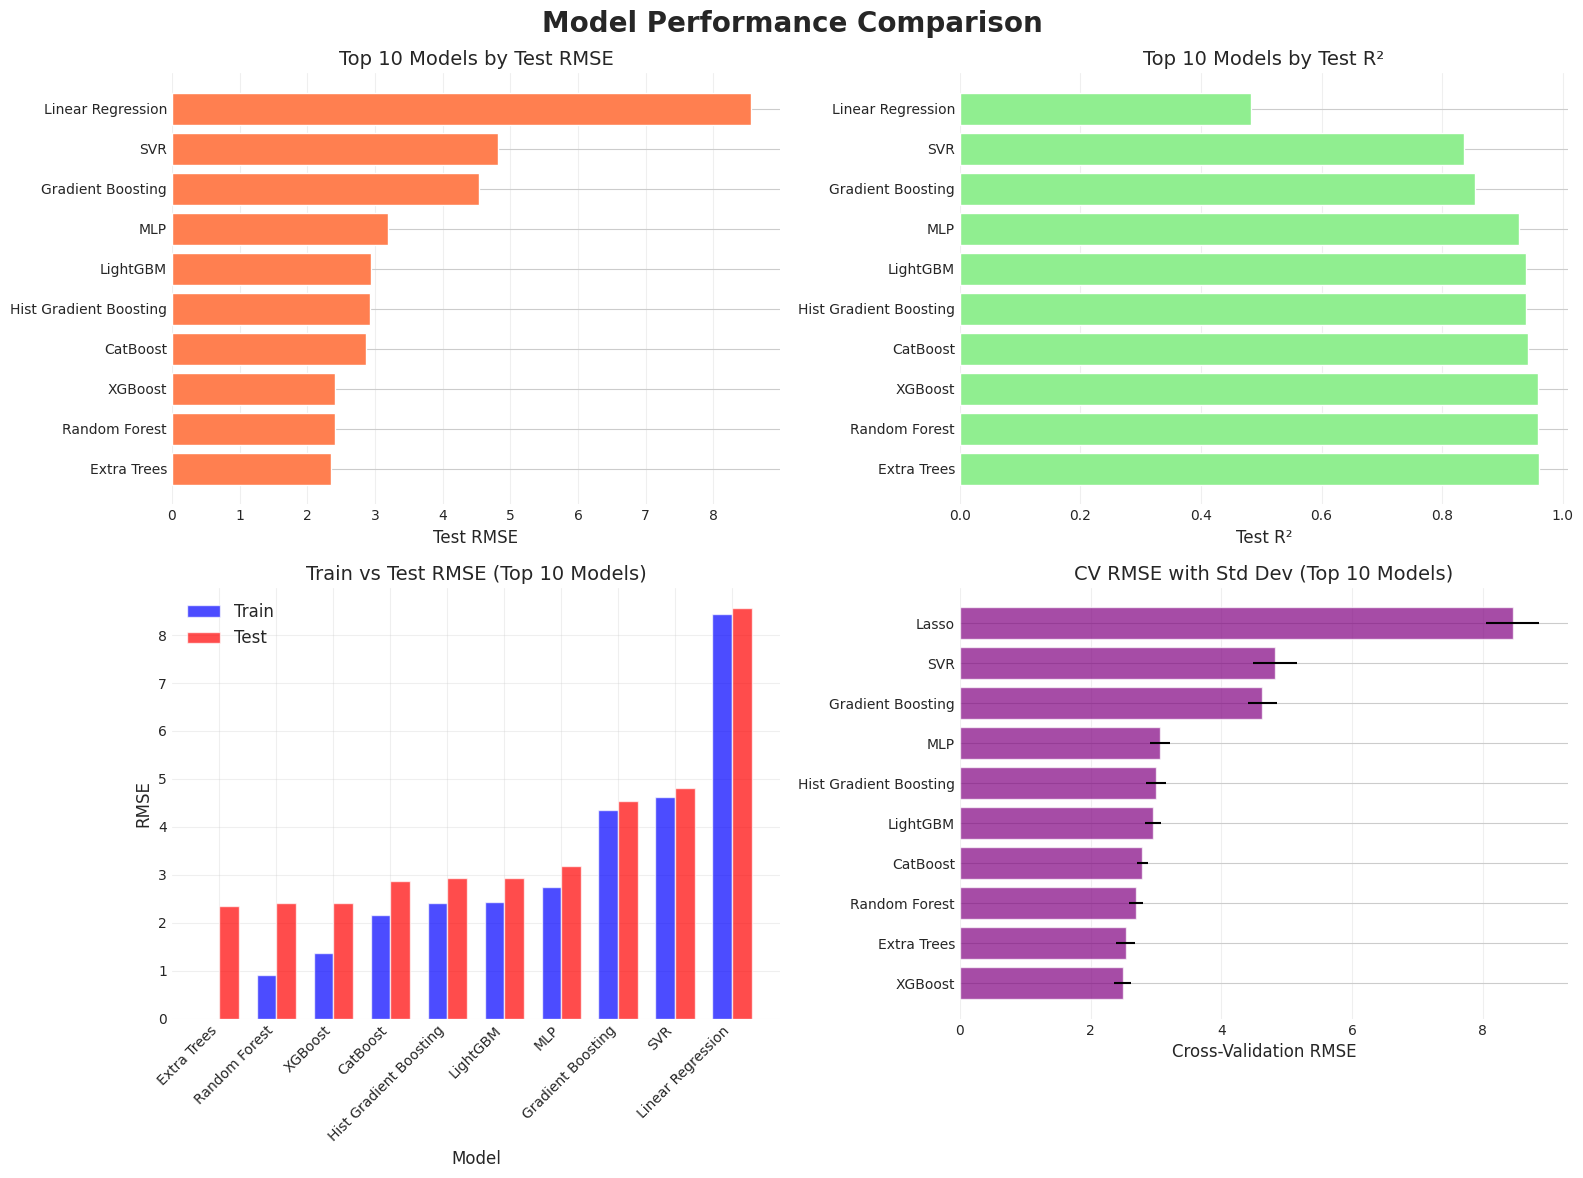

In [13]:


# Create model comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison', fontsize=20, fontweight='bold')

# 1. Test RMSE comparison (top 10)
sorted_rmse = results_df.nsmallest(10, 'Test RMSE')
axes[0, 0].barh(sorted_rmse['Model'], sorted_rmse['Test RMSE'], color='coral')
axes[0, 0].set_xlabel('Test RMSE')
axes[0, 0].set_title('Top 10 Models by Test RMSE')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. Test R2 comparison (top 10)
sorted_r2 = results_df.nlargest(10, 'Test R2')
axes[0, 1].barh(sorted_r2['Model'], sorted_r2['Test R2'], color='lightgreen')
axes[0, 1].set_xlabel('Test R²')
axes[0, 1].set_title('Top 10 Models by Test R²')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. Train vs Test RMSE (top 10 by test RMSE)
top_models = results_df.nsmallest(10, 'Test RMSE')
x = np.arange(len(top_models))
width = 0.35
axes[1, 0].bar(x - width/2, top_models['Train RMSE'], width, label='Train', color='blue', alpha=0.7)
axes[1, 0].bar(x + width/2, top_models['Test RMSE'], width, label='Test', color='red', alpha=0.7)
axes[1, 0].set_xlabel('Model')
axes[1, 0].set_ylabel('RMSE')
axes[1, 0].set_title('Train vs Test RMSE (Top 10 Models)')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(top_models['Model'], rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. CV RMSE with error bars
sorted_cv = results_df.nsmallest(10, 'CV RMSE')
axes[1, 1].barh(sorted_cv['Model'], sorted_cv['CV RMSE'], color='purple', alpha=0.7,
                xerr=sorted_cv['CV RMSE Std'])
axes[1, 1].set_xlabel('Cross-Validation RMSE')
axes[1, 1].set_title('CV RMSE with Std Dev (Top 10 Models)')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Best Model Analysis


BEST MODEL PERFORMANCE METRICS:
R² Score: 0.9610
RMSE: 2.3504
MAE: 1.0028
MAPE: inf%


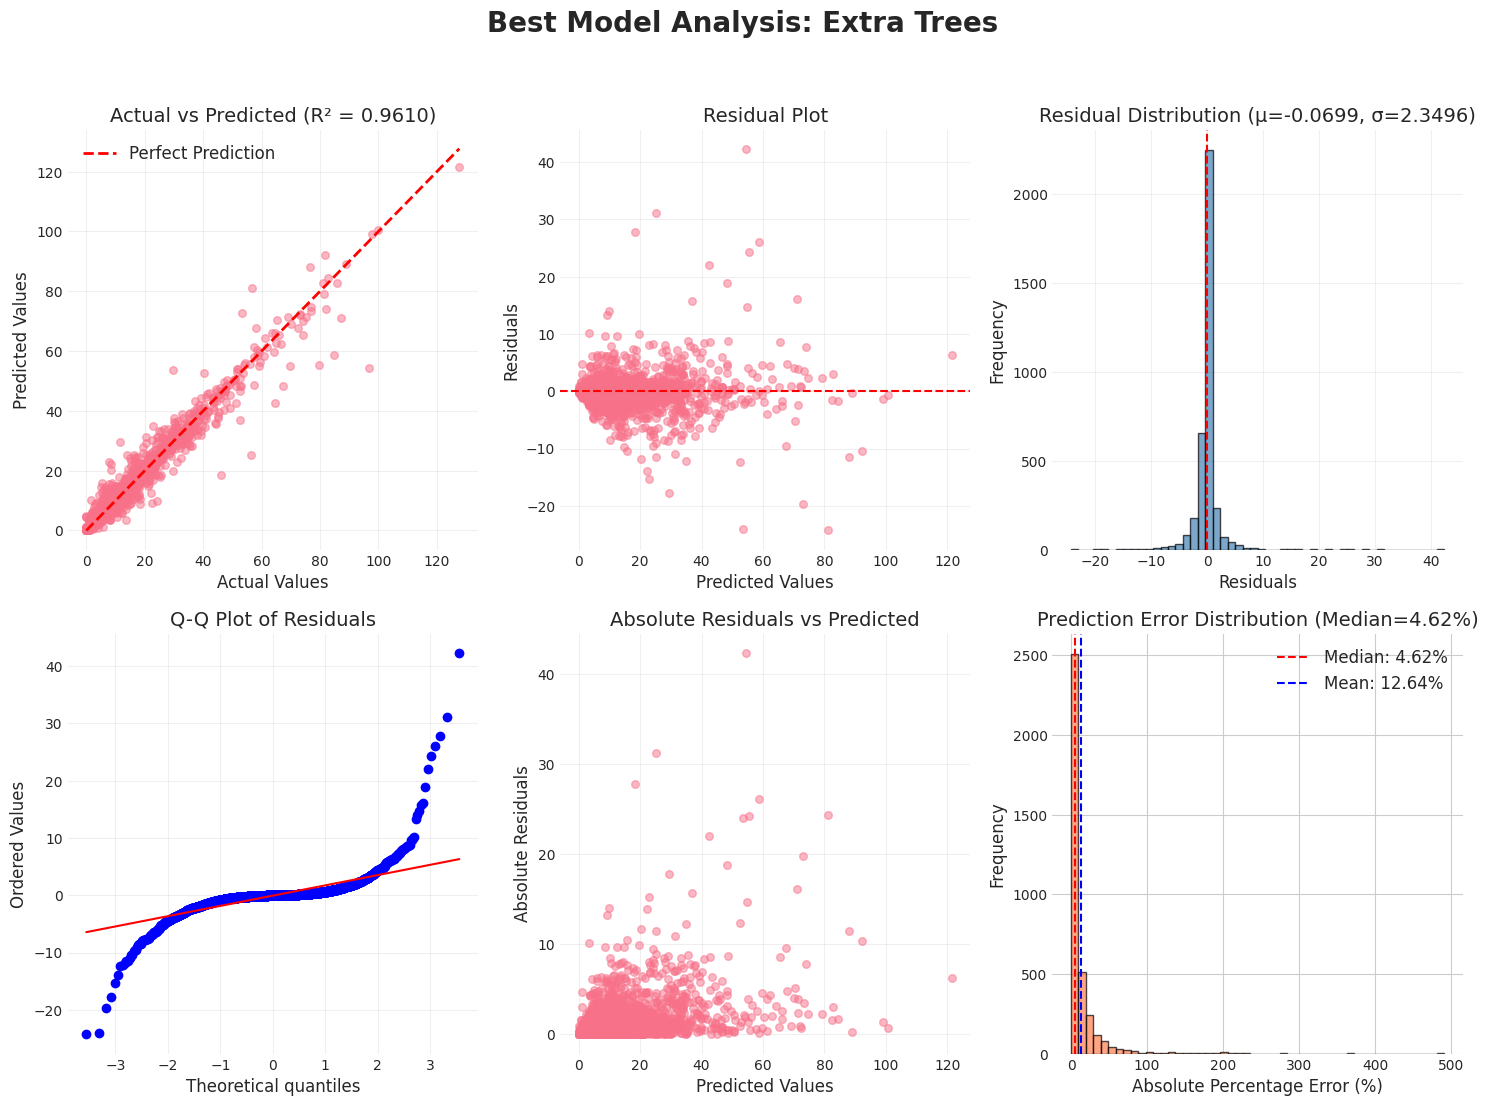

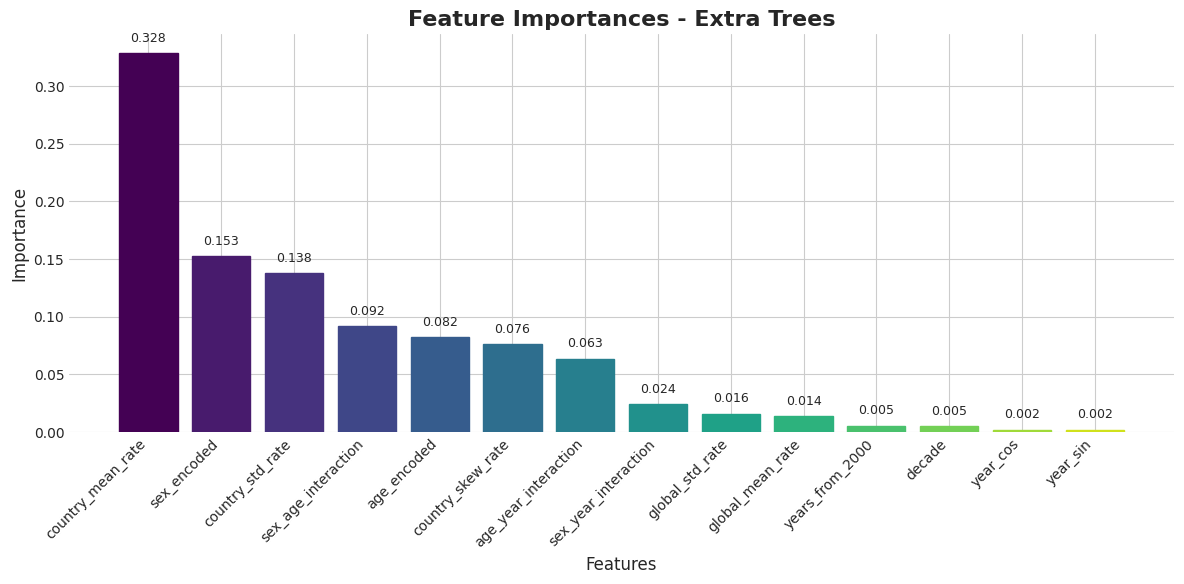


Top 5 Most Important Features:
   1. country_mean_rate: 0.3284
   2. sex_encoded: 0.1526
   3. country_std_rate: 0.1376
   4. sex_age_interaction: 0.0916
   5. age_encoded: 0.0822


In [14]:



# Retrain best model on full training data
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

# Calculate residuals
residuals = y_test - y_pred

# Prediction analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'Best Model Analysis: {best_model_name}', fontsize=20, fontweight='bold')

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred, alpha=0.5, s=30)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Values')
axes[0, 0].set_ylabel('Predicted Values')
axes[0, 0].set_title(f'Actual vs Predicted (R² = {r2_score(y_test, y_pred):.4f})')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals vs Predicted
axes[0, 1].scatter(y_pred, residuals, alpha=0.5, s=30)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# 3. Residual Distribution
axes[0, 2].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 2].axvline(x=0, color='r', linestyle='--')
axes[0, 2].set_xlabel('Residuals')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title(f'Residual Distribution (μ={residuals.mean():.4f}, σ={residuals.std():.4f})')
axes[0, 2].grid(True, alpha=0.3)

# 4. Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot of Residuals')
axes[1, 0].grid(True, alpha=0.3)

# 5. Residuals by predicted value (zoomed)
axes[1, 1].scatter(y_pred, np.abs(residuals), alpha=0.5, s=30)
axes[1, 1].set_xlabel('Predicted Values')
axes[1, 1].set_ylabel('Absolute Residuals')
axes[1, 1].set_title('Absolute Residuals vs Predicted')
axes[1, 1].grid(True, alpha=0.3)


# 6. Prediction error distribution
# Handle infinite and NaN values
error_pct = np.abs(residuals / y_test) * 100

# Remove infinite and NaN values
error_pct_clean = error_pct[np.isfinite(error_pct)]

if len(error_pct_clean) > 0:
    axes[1, 2].hist(error_pct_clean, bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[1, 2].set_xlabel('Absolute Percentage Error (%)')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].set_title(f'Prediction Error Distribution (Median={np.median(error_pct_clean):.2f}%)')
    
    # Add statistics
    axes[1, 2].axvline(np.median(error_pct_clean), color='red', linestyle='--', 
                       label=f'Median: {np.median(error_pct_clean):.2f}%')
    axes[1, 2].axvline(np.mean(error_pct_clean), color='blue', linestyle='--', 
                       label=f'Mean: {np.mean(error_pct_clean):.2f}%')
    axes[1, 2].legend()
else:
    axes[1, 2].text(0.5, 0.5, 'No valid percentage errors to display', 
                    ha='center', va='center', transform=axes[1, 2].transAxes)
    axes[1, 2].set_title('Prediction Error Distribution (No valid data)')

# Print performance metrics
print("\nBEST MODEL PERFORMANCE METRICS:")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MAPE: {np.mean(np.abs((y_test - y_pred) / y_test)) * 100:.2f}%")

# %%
# Feature Importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(12, 6))
    plt.title(f'Feature Importances - {best_model_name}', fontsize=16, fontweight='bold')
    bars = plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), [feature_cols[i] for i in indices], rotation=45, ha='right')
    plt.xlabel('Features')
    plt.ylabel('Importance')
    
    # Color bars by importance
    for i, bar in enumerate(bars):
        bar.set_color(plt.cm.viridis(i/len(bars)))
    
    # Add value labels
    for i, v in enumerate(importances[indices]):
        plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 Most Important Features:")
    for i in range(min(5, len(feature_cols))):
        print(f"   {i+1}. {feature_cols[indices[i]]}: {importances[indices[i]]:.4f}")


#  Clustering Analysis

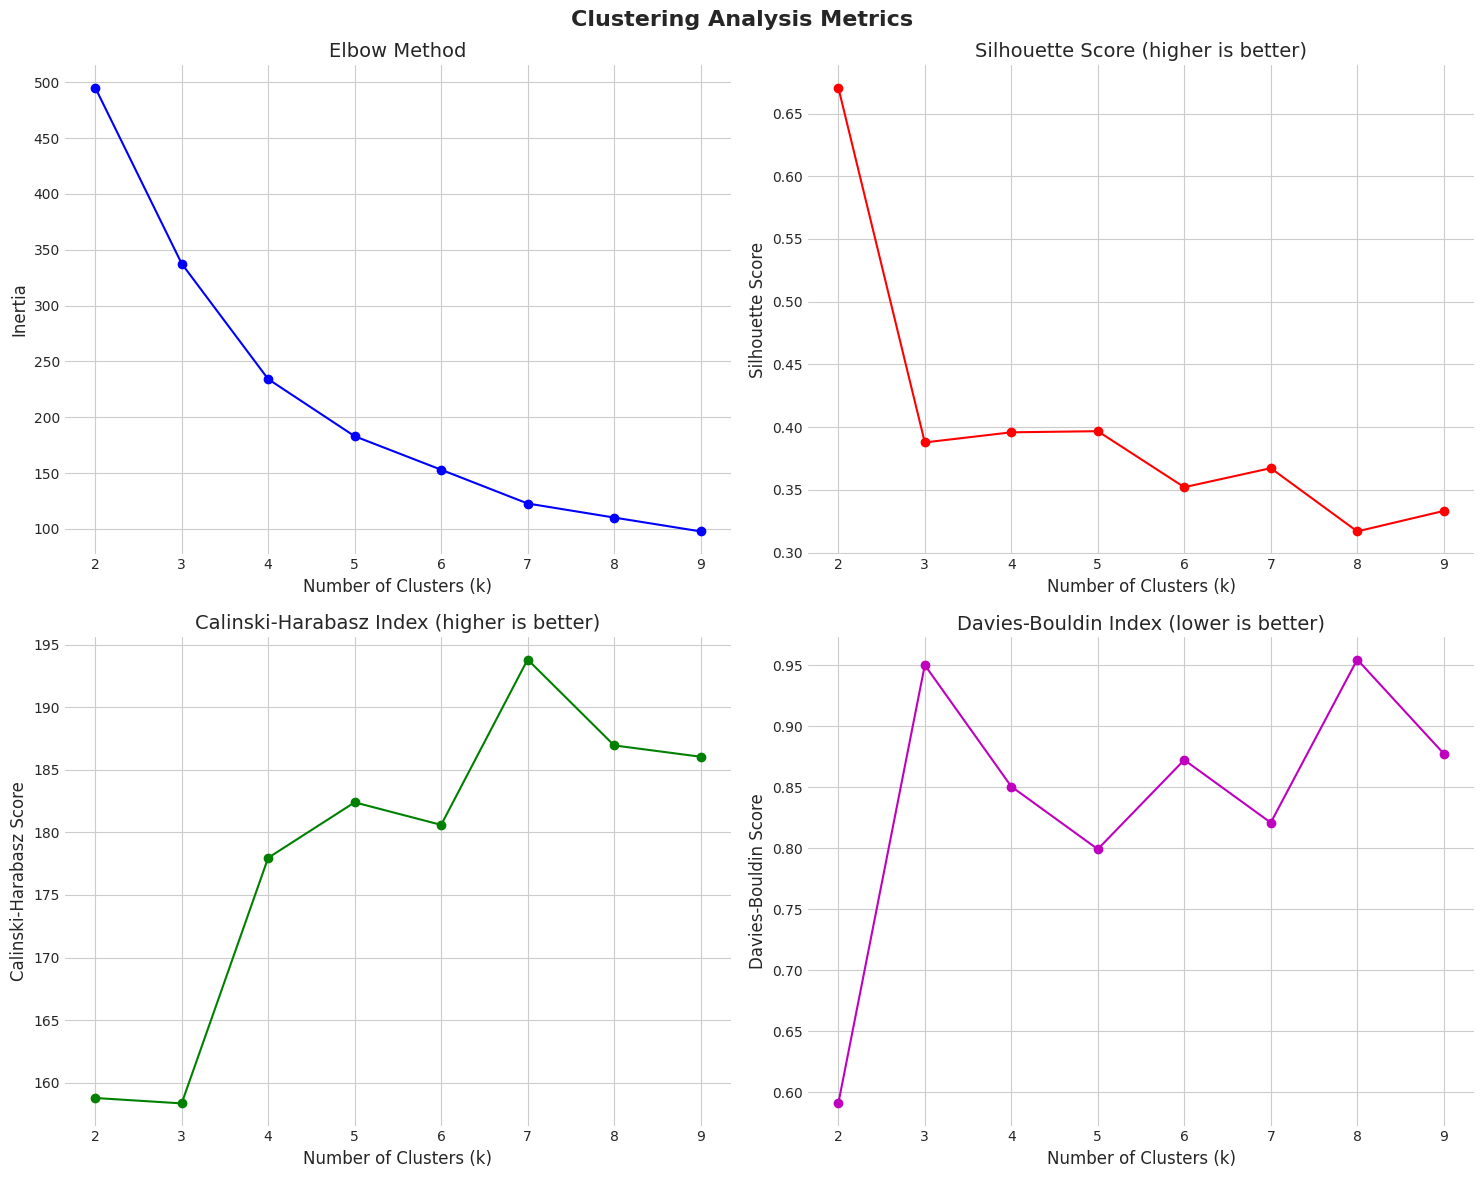


Optimal number of clusters (by silhouette score): 2


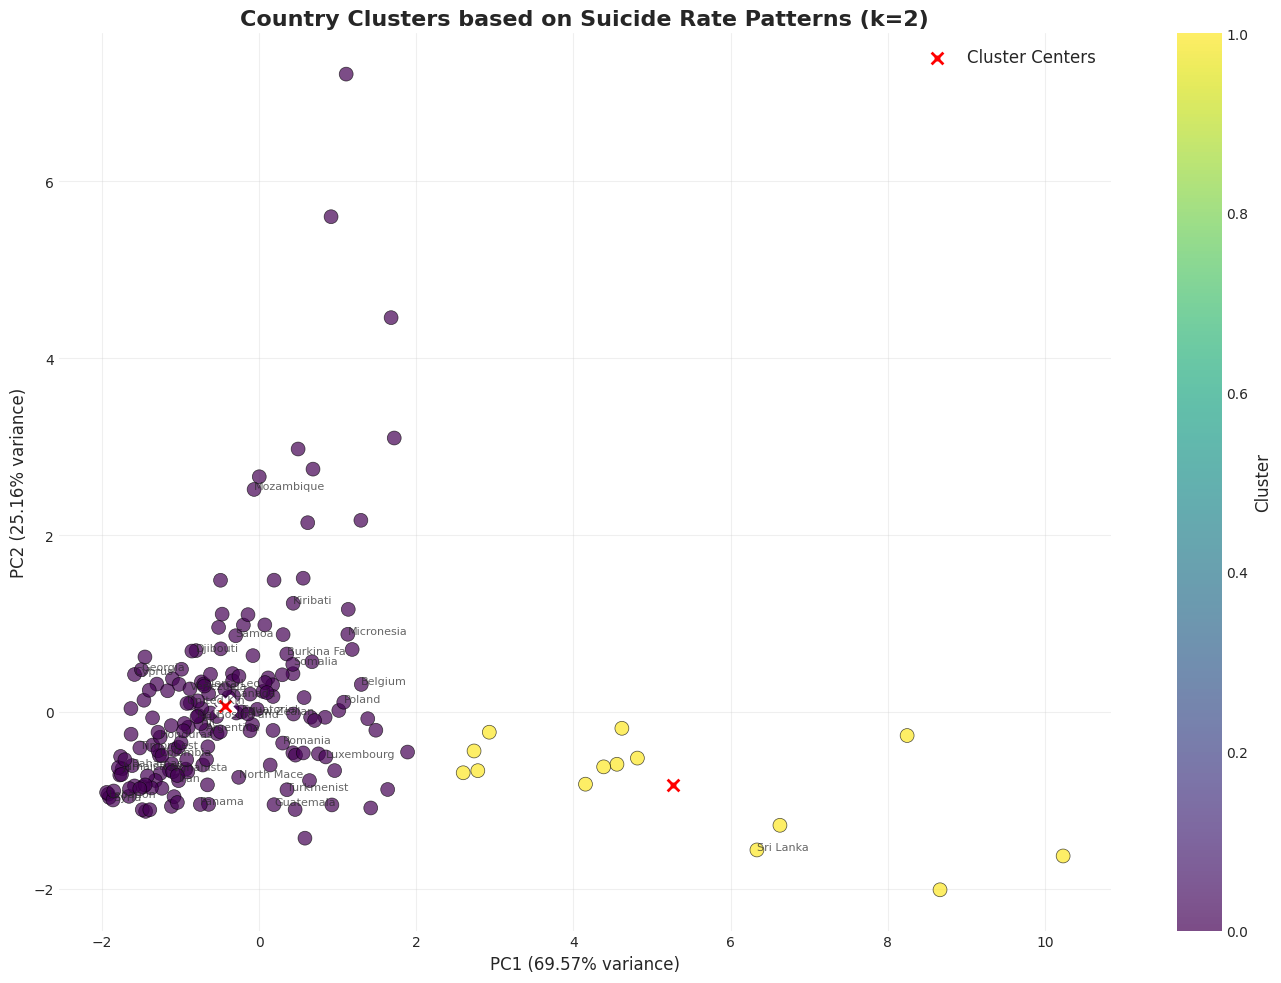

CLUSTER CHARACTERISTICS

 Cluster 0:
  Number of countries: 171
  Sample countries: Afghanistan, Albania, Algeria, Angola, Antigua and Barbuda
  Mean rate: 8.38  5.51
  Avg trend: -0.015 ( increasing /  decreasing)
  Avg volatility: 1.42

 Cluster 1:
  Number of countries: 14
  Sample countries: Belarus, Estonia, Finland, Hungary, Japan
  Mean rate: 24.74  6.13
  Avg trend: -0.813 ( increasing /  decreasing)
  Avg volatility: 5.51


In [15]:

country_features = df[df['sex'] == 'both'].pivot_table(
    values='suicide_rate',
    index='country',
    columns='year',
    aggfunc='mean'
).fillna(method='ffill', axis=1).fillna(method='bfill', axis=1)

# Add summary statistics
country_features['mean_rate'] = country_features.mean(axis=1)
country_features['trend'] = country_features.apply(
    lambda x: np.polyfit(range(len(x)-2), x.iloc[:-2], 1)[0] if len(x) > 2 else 0, 
    axis=1
)
country_features['volatility'] = country_features.iloc[:, :-2].std(axis=1)
country_features['max_rate'] = country_features.iloc[:, :-2].max(axis=1)
country_features['min_rate'] = country_features.iloc[:, :-2].min(axis=1)

# Scale features
feature_cols_cluster = ['mean_rate', 'trend', 'volatility', 'max_rate', 'min_rate']
X_cluster = country_features[feature_cols_cluster].values
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Find optimal number of clusters
inertias = []
silhouette_scores = []
calinski_scores = []
davies_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_cluster_scaled, labels))
    davies_scores.append(davies_bouldin_score(X_cluster_scaled, labels))

# Plot clustering metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Clustering Analysis Metrics', fontsize=16, fontweight='bold')

axes[0, 0].plot(K_range, inertias, 'bo-')
axes[0, 0].set_xlabel('Number of Clusters (k)')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_title('Elbow Method')
axes[0, 0].grid(True)

axes[0, 1].plot(K_range, silhouette_scores, 'ro-')
axes[0, 1].set_xlabel('Number of Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_title('Silhouette Score (higher is better)')
axes[0, 1].grid(True)

axes[1, 0].plot(K_range, calinski_scores, 'go-')
axes[1, 0].set_xlabel('Number of Clusters (k)')
axes[1, 0].set_ylabel('Calinski-Harabasz Score')
axes[1, 0].set_title('Calinski-Harabasz Index (higher is better)')
axes[1, 0].grid(True)

axes[1, 1].plot(K_range, davies_scores, 'mo-')
axes[1, 1].set_xlabel('Number of Clusters (k)')
axes[1, 1].set_ylabel('Davies-Bouldin Score')
axes[1, 1].set_title('Davies-Bouldin Index (lower is better)')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Perform clustering with optimal k (using silhouette score)
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters (by silhouette score): {optimal_k}")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
country_clusters = kmeans.fit_predict(X_cluster_scaled)

# Add cluster labels
country_features['cluster'] = country_clusters

# Visualize clusters with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(14, 10))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=country_clusters, cmap='viridis', 
                      s=100, alpha=0.7, edgecolors='black', linewidth=0.5)

# Add cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], 
           c='red', marker='X', s=200, linewidths=3, 
           edgecolors='white', label='Cluster Centers')

# Add country labels for some points
for i, (idx, row) in enumerate(country_features.iterrows()):
    if i % 5 == 0:  # Label every 5th country
        plt.annotate(idx[:10], (X_pca[i, 0], X_pca[i, 1]), 
                    fontsize=8, alpha=0.7)

plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'Country Clusters based on Suicide Rate Patterns (k={optimal_k})', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display cluster characteristics

print("CLUSTER CHARACTERISTICS")

for cluster in range(optimal_k):
    cluster_countries = country_features[country_features['cluster'] == cluster].index.tolist()
    cluster_data = country_features[country_features['cluster'] == cluster]
    
    print(f"\n Cluster {cluster}:")
    print(f"  Number of countries: {len(cluster_countries)}")
    print(f"  Sample countries: {', '.join(cluster_countries[:5])}")
    print(f"  Mean rate: {cluster_data['mean_rate'].mean():.2f}  {cluster_data['mean_rate'].std():.2f}")
    print(f"  Avg trend: {cluster_data['trend'].mean():.3f} ( increasing /  decreasing)")
    print(f"  Avg volatility: {cluster_data['volatility'].mean():.2f}")


# Final Report and Conclusions

In [16]:





print(" FINAL ANALYSIS REPORT: GLOBAL SUICIDE RATES (2000-2021)")


print("\n DATASET OVERVIEW")
print(f"   • Time Period: {df['year'].min()}-{df['year'].max()} ({df['year'].nunique()} years)")
print(f"   • Countries: {df['country'].nunique()}")
print(f"   • Total Records: {len(df):,}")
print(f"   • Data Completeness: {(1 - df.isnull().sum().sum()/(len(df)*len(df.columns)))*100:.1f}%")

print("\n  KEY STATISTICS")
print(f"   • Global Mean Suicide Rate: {df['suicide_rate'].mean():.2f} per 100,000")
print(f"   • Global Median: {df['suicide_rate'].median():.2f}")
print(f"   • Standard Deviation: {df['suicide_rate'].std():.2f}")
print(f"   • Range: [{df['suicide_rate'].min():.2f}, {df['suicide_rate'].max():.2f}]")

print("\n DEMOGRAPHIC INSIGHTS")
gender_stats = df.groupby('sex')['suicide_rate'].mean()
print(f"   • Male Rate: {gender_stats['male']:.2f}")
print(f"   • Female Rate: {gender_stats['female']:.2f}")
print(f"   • Gender Ratio (M:F): {(gender_stats['male']/gender_stats['female']):.1f}:1")

age_stats = df[df['age_group'] != 'ALL'].groupby('age_group')['suicide_rate'].mean().sort_values(ascending=False)
print(f"   • Highest Risk Age Group: {age_stats.index[0]} ({age_stats.iloc[0]:.2f})")
print(f"   • Lowest Risk Age Group: {age_stats.index[-1]} ({age_stats.iloc[-1]:.2f})")

print("\n  TEMPORAL TRENDS")
yearly_change = df.groupby('year')['suicide_rate'].mean().pct_change().mean() * 100
print(f"   • Average Yearly Change: {yearly_change:.2f}%")
first_year = df[df['year'] == df['year'].min()]['suicide_rate'].mean()
last_year = df[df['year'] == df['year'].max()]['suicide_rate'].mean()
total_change = ((last_year - first_year) / first_year) * 100
print(f"   • Total Change ({df['year'].min()}-{df['year'].max()}): {total_change:.1f}%")

print("\n  GEOGRAPHIC INSIGHTS")
country_stats = df[df['sex'] == 'both'].groupby('country')['suicide_rate'].mean().sort_values(ascending=False)
print(f"   • Highest Rate Country: {country_stats.index[0]} ({country_stats.iloc[0]:.2f})")
print(f"   • Lowest Rate Country: {country_stats.index[-1]} ({country_stats.iloc[-1]:.2f})")

print("\n MODEL PERFORMANCE")
if not results_df.empty:
    best_model = results_df.loc[results_df['Test R2'].idxmax()]
    print(f"   • Best Model: {best_model['Model']}")
    print(f"   • Test R²: {best_model['Test R2']:.4f}")
    print(f"   • Test RMSE: {best_model['Test RMSE']:.4f}")
    print(f"   • Test MAE: {best_model['Test MAE']:.4f}")

print("\n CLUSTERING INSIGHTS")
print(f"   • Optimal Number of Country Clusters: {optimal_k}")
for cluster in range(optimal_k):
    cluster_size = sum(country_clusters == cluster)
    cluster_mean = country_features[country_features['cluster'] == cluster]['mean_rate'].mean()
    print(f"   • Cluster {cluster}: {cluster_size} countries (mean rate: {cluster_mean:.2f})")


print("Fahh Successfully")

 FINAL ANALYSIS REPORT: GLOBAL SUICIDE RATES (2000-2021)

 DATASET OVERVIEW
   • Time Period: 2000-2021 (22 years)
   • Countries: 185
   • Total Records: 18,315
   • Data Completeness: 100.0%

  KEY STATISTICS
   • Global Mean Suicide Rate: 10.41 per 100,000
   • Global Median: 6.84
   • Standard Deviation: 11.53
   • Range: [0.00, 160.59]

 DEMOGRAPHIC INSIGHTS
   • Male Rate: 15.93
   • Female Rate: 5.01
   • Gender Ratio (M:F): 3.2:1
   • Highest Risk Age Group: 70_PLUS (25.93)
   • Lowest Risk Age Group: 10_19 (3.63)

  TEMPORAL TRENDS
   • Average Yearly Change: 0.87%
   • Total Change (2000-2021): 13.3%

  GEOGRAPHIC INSIGHTS
   • Highest Rate Country: Russia (31.93)
   • Lowest Rate Country: Syria (0.74)

 MODEL PERFORMANCE
   • Best Model: Extra Trees
   • Test R²: 0.9610
   • Test RMSE: 2.3504
   • Test MAE: 1.0028

 CLUSTERING INSIGHTS
   • Optimal Number of Country Clusters: 2
   • Cluster 0: 171 countries (mean rate: 8.38)
   • Cluster 1: 14 countries (mean rate: 24.74)
Fa

#  Summary

 ## What We Did

   - Data Processing
      - Cleaned and processed **WHO suicide data** (2000–2021, 185 countries)  
      - Explored trends by **year, sex, age, and country**

   - Machine Learning & Analysis
      - Built and compared **14+ ML models**  
      - Performed **clustering**, **feature importance**, and **SHAP explainability**  

##  Visualizations

* Created **heatmaps**, **time trends**, and **interactive dashboards**  

---
## Why It Matters
   - **700,000+ suicides per year** globally  
   - Large **disparities by gender, age, and region**  
   - Urgent need for **predictive tools and policy guidance**  

---

## Key Insights
* **High-risk groups:** Elderly males, 50–69 age, Eastern Europe  
* **Best predictive model:** Extra Trees (**R² = 0.961**)  
* **Clusters:** Countries grouped by **similar suicide patterns**  
* **Trends:** Overall **global decrease**, but **youth rates rising**  

---
